<a href="https://colab.research.google.com/github/HamzaEric/Pet_Breed_Classification/blob/main/Notebooks/CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import os
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
import copy

# **CNN Architecture**

```text
Input (3×128×128)
│
├── Conv2d (3→16) + ReLU + MaxPool
│
├── Conv2d (16→32) + ReLU + MaxPool
│
├── Flatten → Linear (32×32×32 → 128) + ReLU
│
└── Linear (128 → 37) → Softmax
```

100%|██████████| 792M/792M [00:21<00:00, 37.1MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 19.2MB/s]


Train size: 2944
Validation size: 736
Test size: 3669
Number of classes: 37
Example classes: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']


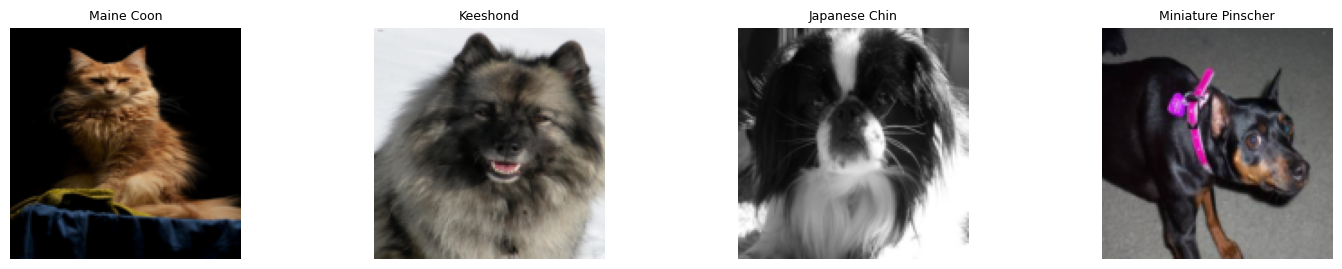

In [3]:
IMG_SIZE = 128

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # scale to [-1,1]
])

trainval_dataset = datasets.OxfordIIITPet(
    root="./data/",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

# Test set
test_dataset = datasets.OxfordIIITPet(
    root="./data/",
    split="test",
    target_types="category",
    transform=transform,
    download=True
)

val_ratio = 0.2
train_size = int((1 - val_ratio) * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size])

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Number of classes: {len(trainval_dataset.classes)}")
print(f"Example classes: {trainval_dataset.classes[:5]}")

# -----------------------------
# 6. Visualize a batch
# -----------------------------
def show_batch(loader, classes, n=4):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, n, figsize=(18, 3))
    for i in range(n):
        img = images[i] * 0.5 + 0.5  # unnormalize to [0,1] for display
        axes[i].imshow(np.transpose(img.numpy(), (1, 2, 0)))
        axes[i].set_title(classes[labels[i]], fontsize=9)
        axes[i].axis("off")
    plt.show()

show_batch(train_loader, trainval_dataset.classes)


### **3. CNN Architecture Design (Conceptual)**

**Baseline CNN Structure**

We will design a **simple yet powerful CNN** to classify the 37 pet breeds:

- **2 Convolution Layers** (extract low- and mid-level features)
- **ReLU Activation** (introduce non-linearity)
- **Max Pooling** (downsample feature maps)
- **Flatten Layer** (convert 3D feature maps to 1D vector)
- **2 Fully Connected Layers (FC)** (combine features for classification)
- **Output Layer (Softmax)** (37-class probability distribution)

**Architecture Overview (ASCII)**

```text
Input: 3 × 128 × 128
│
├── Conv1: 16 filters (3×3) → ReLU → MaxPool (2×2)
│
├── Conv2: 32 filters (3×3) → ReLU → MaxPool (2×2)
│
├── Flatten → FC1 (128 units) → ReLU
│
└── FC2 (37 units) → Softmax
```

**Assumptions for Shape Calculations**

- **Kernel size:** $3 \times 3$ (both Conv layers)  
- **Padding:** $1$ (keeps spatial size same after convolution)  
- **Stride (Conv):** $1$  
- **Pooling:** $2 \times 2$ max pooling (halves spatial dimensions)  

**Formula for Convolution Output Size**

For an input with spatial dimension $H \times W$:

$$
H_{out} = \frac{H + 2P - K}{S} + 1, \qquad
W_{out} = \frac{W + 2P - K}{S} + 1
$$

Where:
- $K$ = kernel size
- $P$ = padding
- $S$ = stride

For pooling ($2 \times 2$, stride 2):

$$
H_{out} = \frac{H}{2}, \qquad W_{out} = \frac{W}{2}
$$


**Shape Transformations (Step-by-Step)**

| Layer                           | Input Shape    | Output Shape   | Operation Details                    |
| ------------------------------- | -------------- | -------------- | ------------------------------------ |
| **Input**                       | $3 \times 128 \times 128$  | $3 \times 128 \times 128$  | Raw RGB image                        |
| **Conv1 (3→16, k=3,p=1,s=1)**   | $3 \times 128 \times 128$  | $16 \times 128 \times 128$ | Computed using formula: $128 = \frac{128 + 2(1) - 3}{1} + 1$ |
| **MaxPool1 (2×2)**              | $16 \times 128 \times 128$ | $16 \times 64 \times 64$   | Downsample: $128 / 2 = 64$           |
| **Conv2 (16→32, k=3,p=1,s=1)**  | $16 \times 64 \times 64$   | $32 \times 64 \times 64$   | Computed similarly with padding 1    |
| **MaxPool2 (2×2)**              | $32 \times 64 \times 64$   | $32 \times 32 \times 32$   | Downsample: $64 / 2 = 32$            |
| **Flatten**                     | $32 \times 32 \times 32$   | $32,768$                     | Convert 3D tensor to 1D vector       |
| **FC1 (32,768→128)**            | $32,768$                     | $128$                        | Combine features, apply ReLU         |
| **FC2 (128→37)**                | $128$                        | $37$                         | Class logits for 37 breeds           |

<br>

> **Why This Architecture?**

**Progressive Feature Learning**
- **First Conv layer:** captures edges and colors.
- **Second Conv layer:** captures textures and patterns (e.g., fur details).

**Pooling Layers**
- Reduce computational cost and add translation invariance.

**Fully Connected Layers**
- Integrate high-level features for final classification.




In [5]:
class PetCNN(nn.Module):
    def __init__(self):
        super(PetCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)  # Input: 3x128x128 → 16x128x128
        self.pool = nn.MaxPool2d(2, 2)                                                   # Downsample → 16x64x64
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1) # 16x64x64 → 32x64x64

        # Fully connected layers
        self.fc1 = nn.Linear(32 * 32 * 32, 128)   # Flatten: 32x32x32 → 128
        self.fc2 = nn.Linear(128, 37)             # 37 classes (pet breeds)

    def forward(self, x):
        # Input: 3 x 128 x 128
        x = self.pool(F.relu(self.conv1(x)))   # After Conv1+ReLU+Pool → 16 x 64 x 64
        x = self.pool(F.relu(self.conv2(x)))   # After Conv2+ReLU+Pool → 32 x 32 x 32
        x = x.view(-1, 32 * 32 * 32)           # Flatten → 32768
        x = F.relu(self.fc1(x))                # FC1 + ReLU → 128
        x = self.fc2(x)                        # FC2 (logits) → 37
        return x

# Instantiate and print model
model = PetCNN()
print(model)

PetCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=37, bias=True)
)


In [6]:
def count_parameters_by_type(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    conv_params = sum(p.numel() for m in model.modules() if isinstance(m, nn.Conv2d)
                      for p in m.parameters())

    fc_params = sum(p.numel() for m in model.modules() if isinstance(m, nn.Linear)
                    for p in m.parameters())

    print(f"Total trainable parameters: {total_params:,}")
    print(f" - Convolutional layers: {conv_params:,}")
    print(f" - Fully connected layers: {fc_params:,}")

count_parameters_by_type(model)

Total trainable parameters: 4,204,293
 - Convolutional layers: 5,088
 - Fully connected layers: 4,199,205


In [7]:
model_seq = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(16, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Linear(32 * 32 * 32, 128),
    nn.ReLU(),
    nn.Linear(128, 37)
)

print(model_seq)
count_parameters_by_type(model_seq)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=32768, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=37, bias=True)
)
Total trainable parameters: 4,204,293
 - Convolutional layers: 5,088
 - Fully connected layers: 4,199,205


In [9]:
criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [11]:
# Accuracy calculation helper
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return (preds == labels).sum().item() / len(labels)

# Training function
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=5, device='cpu'):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    model.to(device)

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print('-' * 20)

        # Each epoch has train and validation phases
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader

            running_loss = 0.0
            running_corrects = 0
            total_samples = 0

            # Iterate over data
            for inputs, labels in loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Zero gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    # Backward + optimize in train phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Stats
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (outputs.argmax(1) == labels).sum().item()
                total_samples += labels.size(0)

            epoch_loss = running_loss / total_samples
            epoch_acc = running_corrects / total_samples

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_acc)
            else:
                val_losses.append(epoch_loss)
                val_accuracies.append(epoch_acc)

                # Deep copy the model if validation improves
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

    # Time tracking
    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    print(f"Best val loss: {best_loss:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)

    # Save checkpoint
    torch.save(model.state_dict(), "petcnn_best.pth")

    return model, (train_losses, val_losses, train_accuracies, val_accuracies)


In [12]:
device = 'cpu'
model, history = train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=5, device=device)

Epoch 1/5
--------------------
Train Loss: 3.5921 Acc: 0.0462
Val Loss: 3.4872 Acc: 0.0625
Epoch 2/5
--------------------
Train Loss: 3.3345 Acc: 0.0890
Val Loss: 3.3010 Acc: 0.0897
Epoch 3/5
--------------------
Train Loss: 2.8442 Acc: 0.2171
Val Loss: 3.1842 Acc: 0.1345
Epoch 4/5
--------------------
Train Loss: 1.8611 Acc: 0.4796
Val Loss: 3.6446 Acc: 0.1182
Epoch 5/5
--------------------
Train Loss: 0.7884 Acc: 0.7840
Val Loss: 4.5808 Acc: 0.1046
Training complete in 5m 22s
Best val loss: 3.1842


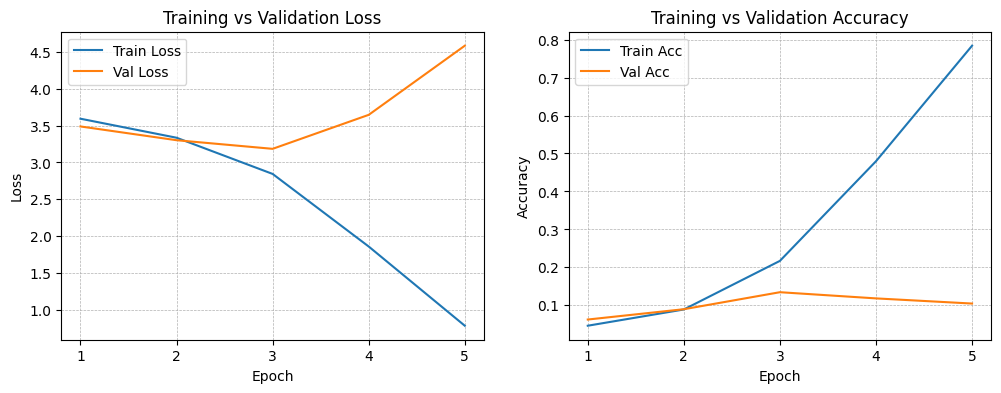

In [13]:
train_losses, val_losses, train_acc, val_acc = history

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12,4))

# Loss plot
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xticks(epochs)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(epochs, train_acc, label='Train Acc')
plt.plot(epochs, val_acc, label='Val Acc')
plt.xticks(epochs)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

**Quick Observation**

- Training loss is **decreasing sharply**, but validation loss is **rising after epoch 3**.  
- Training accuracy climbs steadily (70%+), while validation accuracy **plateaus near 12–15%**.

**What does this mean?**
- The model is **overfitting**: it memorizes training data but fails to generalize to unseen validation data.
- This is expected for our **baseline CNN** — it’s intentionally simple and lacks regularization or augmentation.
